# Generating Embeddings using Hugging Face (Free models)

**Level:** Scratch → Intermediate  
**Runs on:** Google Colab (Free CPU/GPU)

### What you will learn
1. What an embedding is (in simple words)
2. Installing free, open Hugging Face libraries
3. Generating embeddings with sentence-transformers
4. Comparing text similarity using cosine similarity
5. Visualizing embeddings in 2D
6. Building a mini Semantic Search engine (intermediate project)

> No API key needed. No paid model used. Everything here runs on the free Hugging Face open-source models.


## 1. What is an Embedding?

- An embedding is a list of numbers (a vector) that represents the meaning of a piece of text.
- Similar sentences → similar (close) vectors.
- Different sentences → far apart vectors.

**Example:**
- "I love dogs" and "I like puppies" → vectors will be close
- "I love dogs" and "The stock market crashed" → vectors will be far apart

We will use the `sentence-transformers` library, which uses free Hugging Face models.


## 2. Install Required Libraries

Run this once. `-q` keeps the output quiet (low token / clean output).


In [1]:
!pip install -q sentence-transformers scikit-learn matplotlib pandas


## 3. Load a Free Hugging Face Model

We are using `all-MiniLM-L6-v2` — a small, fast, completely free open-source model from Hugging Face.

- Size: ~80MB
- Great for learning and even production use
- Output: 384-dimensional embedding vector per sentence


In [2]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


## 4. Generate Your First Embedding


In [3]:
sentence = "I love learning about Artificial Intelligence."

embedding = model.encode(sentence)

print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])


Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634455 -0.07657029  0.04107473  0.01962831  0.05804771 -0.0507176
  0.0388935   0.03076573  0.05800408  0.06948569]


**Discussion Point:** Notice the embedding has 384 numbers. These numbers don't mean anything individually — but together, they capture the meaning of the sentence.


## 5. Generate Embeddings for Multiple Sentences


In [4]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)


Number of sentences: 5
Embedding matrix shape: (5, 384)


## 6. Measure Similarity Between Sentences

We use Cosine Similarity to check how close two embeddings are.

- Score close to 1 → very similar meaning
- Score close to 0 → unrelated meaning
- Score close to -1 → opposite meaning (rare with text)


In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

df.round(2)


,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


**Important Discussion Point:**

Look at the similarity score between "I love dogs" and "I like puppies" — it should be high.

Compare that to "I love dogs" vs "The stock market crashed today" — it should be low.

This is the core idea behind semantic search, chatbots, and recommendation systems.


## 7. Visualize Embeddings in 2D (using PCA)

Embeddings have 384 dimensions — we can't see that. So we reduce it to 2D just to visualize how sentences cluster.


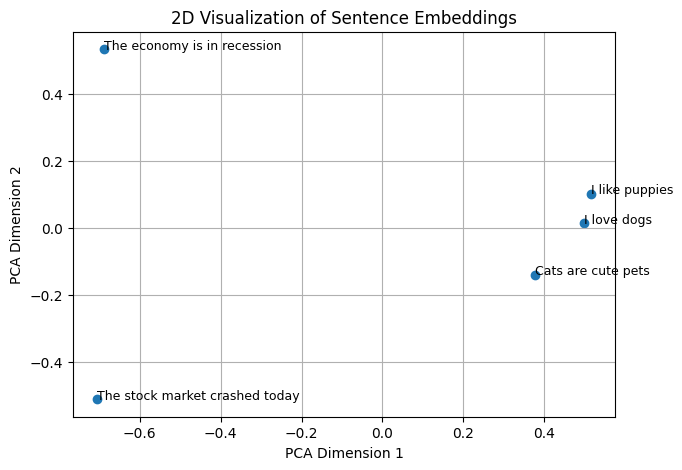

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(
        sent,
        (reduced[i, 0], reduced[i, 1]),
        fontsize=9
    )

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()


**Discussion Point:** Sentences with similar meaning (dogs/puppies, stock/economy) should appear closer together in the plot, even though we never told the model to group them manually.


## 8. Intermediate Project: Mini Semantic Search Engine

**Goal:** Given a user query, find the most relevant sentence from a small database — using meaning, not just matching words.


In [7]:
# Our small "document" database
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")

    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f} | {documents[idx]}")

# Try it
semantic_search("Tell me about AI and neural networks")


Query: Tell me about AI and neural networks

Score: 0.534 | Deep learning uses neural networks with many layers.
Score: 0.524 | Python is a popular programming language for AI.


In [8]:
# Try another query
semantic_search("What is the capital of France?")


Query: What is the capital of France?

Score: 0.824 | Paris is the capital city of France.
Score: 0.102 | Python is a popular programming language for AI.


## 9. Key Takeaways (Recap for Students)

| Concept | Meaning |
|---|---|
| Embedding | Numeric vector representing meaning of text |
| Model used | all-MiniLM-L6-v2 (free, open-source, Hugging Face) |
| Cosine Similarity | Measures how close two embeddings are |
| Semantic Search | Finding relevant text by meaning, not exact words |
| PCA | Used only to visualize high-dimension vectors in 2D |


### 10. Practice Exercises (for students)

1. Replace the documents list with your own 10 sentences and test `semantic_search`.
2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.
3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.


### Exercise 1 — Own 10 sentences and test `semantic_search`


In [9]:
documents = [
    "Python is widely used for data science and machine learning.",
    "Java is a popular programming language for software development.",
    "Machine learning allows computers to learn patterns from data.",
    "Deep learning uses neural networks to solve complex problems.",
    "Natural language processing helps computers understand human language.",
    "Football is a popular sport played by teams around the world.",
    "Healthy food provides the body with essential nutrients.",
    "The weather forecast predicts rain tomorrow.",
    "The capital of India is New Delhi.",
    "Artificial intelligence can be used to build intelligent applications."
]

doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")

    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f} | {documents[idx]}")

semantic_search("How is AI used in machine learning?", top_k=3)


Query: How is AI used in machine learning?

Score: 0.668 | Machine learning allows computers to learn patterns from data.
Score: 0.623 | Artificial intelligence can be used to build intelligent applications.
Score: 0.517 | Deep learning uses neural networks to solve complex problems.


**Observation:** The semantic search returns sentences related to AI and machine learning based on meaning rather than exact word matching.


### Exercise 2 — Try `all-mpnet-base-v2` and compare results


In [10]:
# Load the alternative free Hugging Face model
model_mpnet = SentenceTransformer("all-mpnet-base-v2")

# Use the same documents and query for comparison
mpnet_embeddings = model_mpnet.encode(documents)

query = "How is AI used in machine learning?"

query_embedding_mpnet = model_mpnet.encode([query])
mpnet_scores = cosine_similarity(
    query_embedding_mpnet,
    mpnet_embeddings
)[0]

mpnet_ranked_idx = mpnet_scores.argsort()[::-1][:3]

print("Results using all-mpnet-base-v2:\n")

for idx in mpnet_ranked_idx:
    print(f"Score: {mpnet_scores[idx]:.3f} | {documents[idx]}")

print("\nResults using all-MiniLM-L6-v2:\n")
semantic_search(query, top_k=3)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Results using all-mpnet-base-v2:

Score: 0.657 | Machine learning allows computers to learn patterns from data.
Score: 0.589 | Artificial intelligence can be used to build intelligent applications.
Score: 0.530 | Deep learning uses neural networks to solve complex problems.

Results using all-MiniLM-L6-v2:

Query: How is AI used in machine learning?

Score: 0.668 | Machine learning allows computers to learn patterns from data.
Score: 0.623 | Artificial intelligence can be used to build intelligent applications.
Score: 0.517 | Deep learning uses neural networks to solve complex problems.


**Observation:** Both models can retrieve semantically related sentences. `all-mpnet-base-v2` is a larger model and may produce different similarity scores and rankings.


### Exercise 3 — Build a simple FAQ bot


In [11]:
faq = [
    (
        "What is Python?",
        "Python is a popular programming language used for many applications, including AI and data science."
    ),
    (
        "What is machine learning?",
        "Machine learning is a method where computers learn patterns from data."
    ),
    (
        "What is deep learning?",
        "Deep learning uses neural networks with many layers to learn complex patterns."
    ),
    (
        "What is NLP?",
        "Natural Language Processing helps computers understand and work with human language."
    ),
    (
        "What is semantic search?",
        "Semantic search finds relevant information based on meaning rather than exact keyword matching."
    )
]

faq_questions = [question for question, answer in faq]
faq_answers = [answer for question, answer in faq]

faq_embeddings = model.encode(faq_questions)

def faq_bot(query):
    query_embedding = model.encode([query])

    scores = cosine_similarity(
        query_embedding,
        faq_embeddings
    )[0]

    best_idx = scores.argmax()

    print("Question:", query)
    print("Matched FAQ:", faq_questions[best_idx])
    print("Score:", round(scores[best_idx], 3))
    print("Answer:", faq_answers[best_idx])

faq_bot("Can you explain machine learning?")


Question: Can you explain machine learning?
Matched FAQ: What is machine learning?
Score: 0.847
Answer: Machine learning is a method where computers learn patterns from data.


**Observation:** The FAQ bot encodes the questions, compares the user's query with them using cosine similarity, and returns the answer belonging to the most similar question.
